## BUSINESS UNDERSTANDING

The 2024 Indonesian presidential election has generated immense public discourse on social media, making these platforms a rich source of public opinion. The core problem this project addresses is the classification of public sentiment from social media text, specifically focusing on translated tweets related to Prabowo Subianto and other presidential candidates. By accurately identifying sentiment, we can gauge public reactions, track evolving opinions, and provide a clear picture of the political landscape.

From a machine learning perspective, this is framed as a binary text classification problem using supervised learning. The primary objective is to compare the performance of three specific recurrent neural network (RNN) architectures: LSTM, BiLSTM, and GRU. The business value of this project lies in providing political analysts, campaign managers, and the public with data-driven insights into opinion trends, ultimately demonstrating how deep learning can distill massive amounts of unstructured text into actionable intelligence.

=== DATA UNDERSTANDING - DATA BERSIH ===
File ditemukan: 3 file.

Total Keseluruhan Baris: 30000
Total Kolom: 11
Kolom Teks yang digunakan: 'Text'
Kolom Label yang digunakan: 'label'

Distribusi Label Sentimen:
label
Positive    21654
Negative     8343
Name: count, dtype: int64


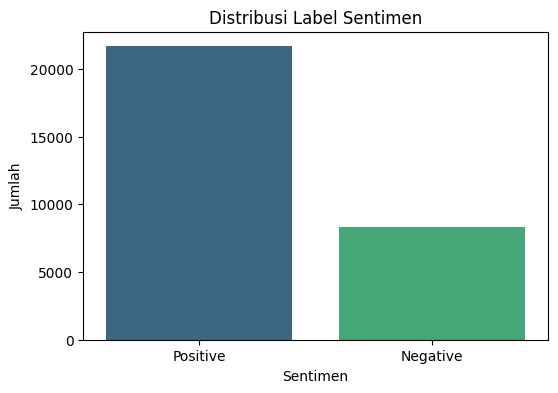


Lima Baris Pertama Data Bersih/Labeled:


,Text,label
0,anies president info,Positive
1,gerindra party politician sandiaga uno answers...,Positive
2,"mr. anies continued, we will guard him until h...",Positive
3,may allah swt save the nation and state of the...,Positive
4,"poor chotimah, uncle anies, that's why my fami...",Positive



Lima Baris Terakhir Data Bersih/Labeled:


,Text,label
29995,"sir, if the community always goes down, it wil...",Positive
29996,"young prabowo is really cool, bismillah sir, g...",Positive
29997,"basically, prabowo is great and was chosen as ...",Positive
29998,optimistic about being the best figure in the ...,Positive
29999,"the best presidential candidate, god willing, ...",Positive


In [ ]:
# ==========================================
# CELL 1: DATA UNDERSTANDING & LOAD DATA BERSIH
# ==========================================
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

print("=== DATA UNDERSTANDING - DATA BERSIH ===")

csv_paths = sorted(glob.glob("data/labeled data/*.csv"))
print(f"File ditemukan: {len(csv_paths)} file.")

if len(csv_paths) > 0:
    df_list = [pd.read_csv(file) for file in csv_paths]
    df = pd.concat(df_list, ignore_index=True)

    text_col = 'Text'
    label_col = 'label'

    print(f"\nTotal Keseluruhan Baris: {df.shape[0]}")
    print(f"Total Kolom: {df.shape[1]}")
    print(f"Kolom Teks yang digunakan: '{text_col}'")
    print(f"Kolom Label yang digunakan: '{label_col}'")

    print("\nDistribusi Label Sentimen:")
    distribusi = df[label_col].value_counts()
    print(distribusi)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=label_col, hue=label_col, palette='viridis', legend=False)
    plt.title('Distribusi Label Sentimen')
    plt.xlabel('Sentimen')
    plt.ylabel('Jumlah')
    plt.show()

    print("\nLima Baris Pertama Data Bersih/Labeled:")
    display(df[[text_col, label_col]].head())

    print("\nLima Baris Terakhir Data Bersih/Labeled:")
    display(df[[text_col, label_col]].tail())
else:
    print("File CSV tidak ditemukan. Pastikan direktori 'data/labeled data/' sudah benar.")


In [3]:
# ==========================================
# CELL 2: PREPROCESSING TEKS & LABEL
# ==========================================
import re

print("=== PREPROCESSING TEKS & LABEL - DATA BERSIH ===")

def clean_text(text):
    text = str(text)
    # Menghapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Hanya menyisakan huruf alfabet dan spasi
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Menghapus spasi yang berlebihan
    text = re.sub(r'\s+', ' ', text).strip()
    # Mengubah teks menjadi huruf kecil
    return text.lower()

# Menerapkan pembersihan teks pada kolom Text dari dataset labeled/bersih
df['cleaned_text'] = df[text_col].apply(clean_text)

# Memfilter data hanya untuk kelas Positive dan Negative
df_clean = df.copy()
df_clean = df_clean.dropna(subset=[label_col, 'cleaned_text'])
df_clean = df_clean[df_clean[label_col].astype(str).str.lower().isin(['positive', 'negative'])]
df_clean = df_clean[df_clean['cleaned_text'].str.len() > 0]

# Mengonversi label ke biner (Positive = 1, Negative = 0)
label_mapping = {'positive': 1, 'negative': 0}
df_clean['target'] = df_clean[label_col].astype(str).str.lower().map(label_mapping)

print(f"Jumlah baris setelah dibersihkan dan difilter: {len(df_clean)}")
print("\nHasil Preprocessing:")
display(df_clean[['cleaned_text', 'target']].head())


=== PREPROCESSING TEKS & LABEL - DATA BERSIH ===
Jumlah baris setelah dibersihkan dan difilter: 29997

Hasil Preprocessing:


,cleaned_text,target
0,anies president info,1
1,gerindra party politician sandiaga uno answers...,1
2,mr anies continued we will guard him until he ...,1
3,may allah swt save the nation and state of the...,1
4,poor chotimah uncle anies that s why my family...,1


In [4]:
# ==========================================
# CELL 3: SPLIT DATA
# ==========================================
from sklearn.model_selection import train_test_split

print("=== SPLIT DATA (TRAIN, VAL, TEST) ===")

# Pertama, pisahkan 80% untuk (Train+Val) dan 20% untuk Test
X_temp, X_test, y_temp, y_test = train_test_split(
    df_clean['cleaned_text'], 
    df_clean['target'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_clean['target']
)

# Kedua, pisahkan sisa 80% tadi menjadi 60% Train dan 20% Validation
# (0.25 dari 80% adalah 20% dari total dataset)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_temp
)

print(f"Data Train: {len(X_train)} baris")
print(f"Data Validation: {len(X_val)} baris")
print(f"Data Test: {len(X_test)} baris")


=== SPLIT DATA (TRAIN, VAL, TEST) ===
Data Train: 17997 baris
Data Validation: 6000 baris
Data Test: 6000 baris


In [5]:
# ==========================================
# CELL 4: TOKENIZATION & PADDING
# ==========================================
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("=== TOKENIZATION & PADDING ===")

# Parameter
vocab_size = 5000       # Maksimal kata unik yang disimpan
max_length = 100        # Panjang maksimal sequence kalimat
oov_tok = "<OOV>"       # Token untuk kata yang tidak ada di vocabulary

# 1. Inisiasi dan Fit Tokenizer pada data Train
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train)

# 2. Mengubah teks menjadi sequences (urutan angka)
train_sequences = tokenizer.texts_to_sequences(X_train)
val_sequences = tokenizer.texts_to_sequences(X_val)
test_sequences = tokenizer.texts_to_sequences(X_test)

# 3. Menyamakan panjang (Padding)
X_train_pad = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
X_val_pad = pad_sequences(val_sequences, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

print("Proses Tokenisasi dan Padding Selesai.")
print(f"Bentuk X_train_pad: {X_train_pad.shape}")
print(f"Bentuk X_val_pad  : {X_val_pad.shape}")
print(f"Bentuk X_test_pad : {X_test_pad.shape}")


=== TOKENIZATION & PADDING ===
Proses Tokenisasi dan Padding Selesai.
Bentuk X_train_pad: (17997, 100)
Bentuk X_val_pad  : (6000, 100)
Bentuk X_test_pad : (6000, 100)


In [6]:
# ==========================================
# CELL 5: SETUP MODEL & CALLBACKS
# ==========================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time

print("=== PERSIAPAN MODELING ===")

# Parameter arsitektur Neural Network
embedding_dim = 128
epochs = 5
batch_size = 64

# Callback: Hentikan training jika val_loss tidak membaik dalam 2 epoch
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Tempat menyimpan history training untuk visualisasi nanti
training_histories = {}


=== PERSIAPAN MODELING ===


In [7]:
# ==========================================
# CELL 6: MODEL LSTM
# ==========================================
print("=== MELATIH MODEL LSTM ===")
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # sigmoid untuk binary classification (0 atau 1)
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()

start_time = time.time()
training_histories['LSTM'] = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop]
)
print(f"Waktu Pelatihan LSTM: {time.time() - start_time:.2f} detik")


=== MELATIH MODEL LSTM ===


c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.7213 - loss: 0.6067 - val_accuracy: 0.7218 - val_loss: 0.5916
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.7219 - loss: 0.6007 - val_accuracy: 0.7218 - val_loss: 0.5916
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.7219 - loss: 0.5973 - val_accuracy: 0.7218 - val_loss: 0.5927
Waktu Pelatihan LSTM: 41.28 detik


In [8]:
# ==========================================
# CELL 7: MODEL BiLSTM
# ==========================================
print("\n=== MELATIH MODEL BiLSTM ===")
model_bilstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_bilstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_bilstm.summary()

start_time = time.time()
training_histories['BiLSTM'] = model_bilstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop]
)
print(f"Waktu Pelatihan BiLSTM: {time.time() - start_time:.2f} detik")



=== MELATIH MODEL BiLSTM ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 73ms/step - accuracy: 0.8165 - loss: 0.4265 - val_accuracy: 0.8765 - val_loss: 0.3132
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.9070 - loss: 0.2528 - val_accuracy: 0.8920 - val_loss: 0.2707
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - accuracy: 0.9328 - loss: 0.1918 - val_accuracy: 0.8957 - val_loss: 0.2610
Epoch 4/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.9479 - loss: 0.1498 - val_accuracy: 0.8963 - val_loss: 0.2659
Epoch 5/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.9553 - loss: 0.1245 - val_accuracy: 0.8993 - val_loss: 0.3140
Waktu Pelatihan BiLSTM: 85.78 detik


In [9]:
# ==========================================
# CELL 8: MODEL GRU
# ==========================================
print("\n=== MELATIH MODEL GRU ===")
model_gru = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    GRU(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_gru.summary()

start_time = time.time()
training_histories['GRU'] = model_gru.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop]
)
print(f"Waktu Pelatihan GRU: {time.time() - start_time:.2f} detik")



=== MELATIH MODEL GRU ===


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.7208 - loss: 0.6035 - val_accuracy: 0.7218 - val_loss: 0.5913
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.7219 - loss: 0.5996 - val_accuracy: 0.7218 - val_loss: 0.5913
Waktu Pelatihan GRU: 27.87 detik


In [10]:
# ==========================================
# CELL 9: EVALUASI MODEL
# ==========================================
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("=== EVALUASI PADA DATA TEST ===")

models = {
    'LSTM': model_lstm,
    'BiLSTM': model_bilstm,
    'GRU': model_gru
}

predictions = {}

for name, model in models.items():
    print(f"\n--- Evaluasi Model {name} ---")
    
    # Memprediksi probabilitas
    y_pred_probs = model.predict(X_test_pad)
    # Mengubah probabilitas menjadi kelas 0 atau 1
    y_pred = (y_pred_probs > 0.5).astype(int)
    predictions[name] = y_pred
    
    # Menghitung Metrik
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    
    # Menampilkan Classification Report lengkap (Precision, Recall, F1-Score)
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


=== EVALUASI PADA DATA TEST ===

--- Evaluasi Model LSTM ---
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Accuracy: 0.7218
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      1669
    Positive       0.72      1.00      0.84      4331

    accuracy                           0.72      6000
   macro avg       0.36      0.50      0.42      6000
weighted avg       0.52      0.72      0.61      6000


--- Evaluasi Model BiLSTM ---


c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Accuracy: 0.8938
              precision    recall  f1-score   support

    Negative       0.81      0.81      0.81      1669
    Positive       0.93      0.92      0.93      4331

    accuracy                           0.89      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.89      0.89      0.89      6000


--- Evaluasi Model GRU ---
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
Accuracy: 0.7218
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      1669
    Positive       0.72      1.00      0.84      4331

    accuracy                           0.72      6000
   macro avg       0.36      0.50      0.42      6000
weighted avg       0.52      0.72      0.61      6000



c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

=== VISUALISASI TRAINING & CONFUSION MATRIX ===


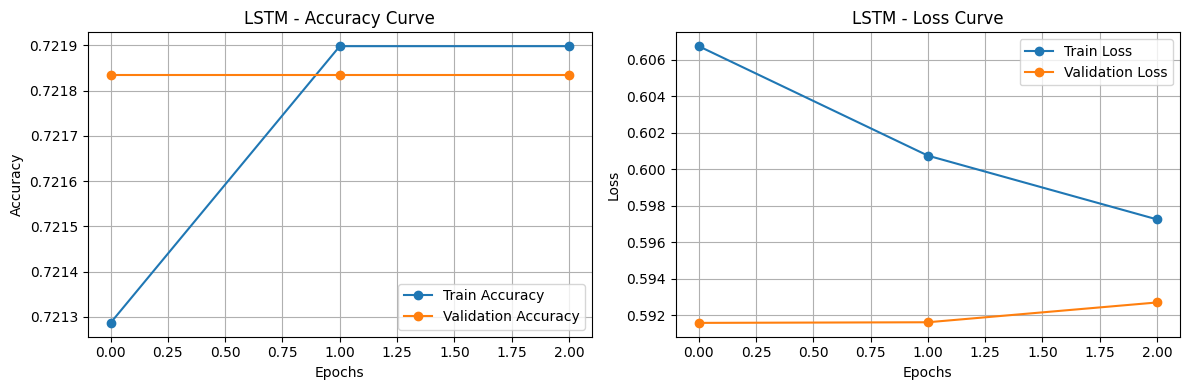

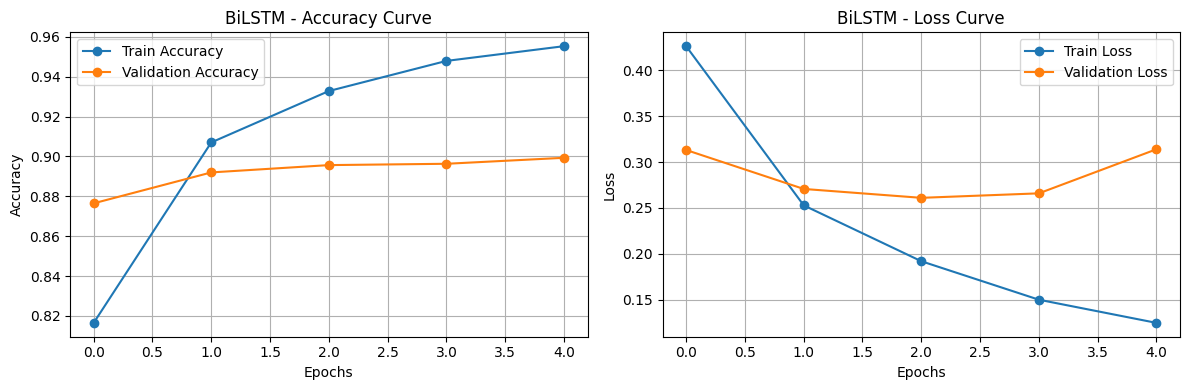

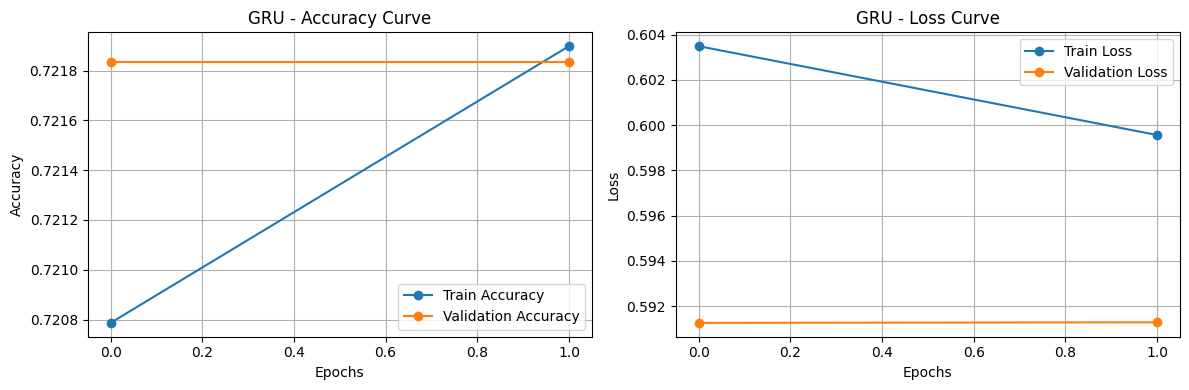

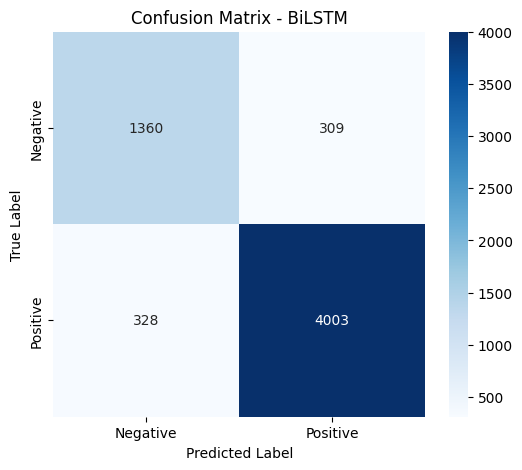

In [11]:
# ==========================================
# CELL 10: VISUALISASI HASIL PELATIHAN
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

print("=== VISUALISASI TRAINING & CONFUSION MATRIX ===")

# 1. Grafik Accuracy dan Loss dari Proses Training
def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Accuracy Plot
    ax1.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    ax1.set_title(f'{model_name} - Accuracy Curve')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Loss Plot
    ax2.plot(history.history['loss'], label='Train Loss', marker='o')
    ax2.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    ax2.set_title(f'{model_name} - Loss Curve')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Menampilkan grafik untuk tiap model
for name, history in training_histories.items():
    plot_history(history, name)

# 2. Confusion Matrix Heatmap (Mengambil model BiLSTM sebagai contoh terbaik)
best_model_name = 'BiLSTM'
cm = confusion_matrix(y_test, predictions[best_model_name])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
